In [26]:
import numpy as np
import pandas as pd
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

DATA_DIR    = Path('../data/processed')
RESULTS_DIR = Path('../results')
FIGURES_DIR = Path('../figures')
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"PyMC version:  {pm.__version__}")
print(f"ArviZ version: {az.__version__}")
print(f"NumPy version: {np.__version__}")


PyMC version:  6.0.0
ArviZ version: 1.1.0
NumPy version: 2.3.3


In [27]:
# ---- Load all processed races ----
# Wet data preserved on disk for Section 12. Dry-pace model filters on
# compound_condition == 'DRY'. Legacy 2025_Hungary.parquet auto-deduped against
# 2025_Budapest.parquet via the (year, circuit) key.
MIN_DRY_LAPS_PER_RACE = 30

raw_files = sorted(Path(DATA_DIR).glob('*.parquet'))
print(f"Found {len(raw_files)} parquet files")

frames, seen = [], set()
for path in raw_files:
    stem = path.stem
    try:
        year_str, location = stem.split('_', 1)
        year = int(year_str)
    except (ValueError, TypeError):
        print(f"  skip (unparseable name): {path.name}")
        continue
    df = pd.read_parquet(path)
    if 'circuit' not in df.columns:
        df['circuit'] = location
    circuit = df['circuit'].iloc[0]
    key = (year, circuit)
    if key in seen:
        print(f"  dedupe: {path.name} (already loaded {circuit} {year})")
        continue
    df['race_id'] = f"{year}_{location}"
    df['season'] = year
    seen.add(key)
    frames.append(df)

raw = pd.concat(frames, ignore_index=True)
TEAM_ALIASES = {'RB': 'Racing Bulls'}
raw['Team'] = raw['Team'].replace(TEAM_ALIASES)

print(f"\nLoaded {len(raw):,} total laps from {len(frames)} races")

df = raw[(raw['anomaly_flag'] == 'normal')
         & (raw['compound_condition'] == 'DRY')].copy().reset_index(drop=True)

race_counts = df.groupby('race_id').size()
sparse_races = race_counts[race_counts < MIN_DRY_LAPS_PER_RACE].index.tolist()
if sparse_races:
    df = df[~df['race_id'].isin(sparse_races)].reset_index(drop=True)

print(f"Final dry-pace dataset: {len(df):,} laps from {df['race_id'].nunique()} races")


Found 49 parquet files
  dedupe: 2025_Hungary.parquet (already loaded Hungarian Grand Prix 2025)

Loaded 53,298 total laps from 48 races
Final dry-pace dataset: 42,491 laps from 47 races


In [32]:
# ---- Build categorical indices ----
race_cat        = pd.Categorical(df['race_id'])
driver_cat      = pd.Categorical(df['Driver'])
constructor_cat = pd.Categorical(df['Team'])
compound_cat    = pd.Categorical(df['Compound'])

df['race_idx']        = race_cat.codes
df['driver_idx']      = driver_cat.codes
df['constructor_idx'] = constructor_cat.codes
df['compound_idx']    = compound_cat.codes

race_names        = race_cat.categories.values
driver_names      = driver_cat.categories.values
constructor_names = constructor_cat.categories.values
compound_names    = compound_cat.categories.values

race_idx        = df['race_idx'].values
driver_idx      = df['driver_idx'].values
constructor_idx = df['constructor_idx'].values
compound_idx    = df['compound_idx'].values

lap_in_stint = df['lap_in_stint'].values.astype(float)
y = df['lap_time_fuel_corrected'].values

n_races        = len(race_names)
n_drivers      = len(driver_names)
n_constructors = len(constructor_names)
n_compounds    = len(compound_names)

print(f"Model dimensions: {n_races} races, {n_drivers} drivers, "
      f"{n_constructors} constructors, {n_compounds} compounds, {len(y):,} obs")
print(f"Response: mean={y.mean():.3f}s, std={y.std():.3f}s")


Model dimensions: 47 races, 27 drivers, 10 constructors, 3 compounds, 42,491 obs
Response: mean=86.530s, std=10.253s


In [33]:
# ---- Pass 1 multi-race model (parsimonious Bell-style) ----
# Foundational structure matching race-grain literature, scaled to lap grain.
# All complex hierarchy (constructor-race, stint random) deferred to Pass 2.

with pm.Model() as model:
    sigma_race        = pm.HalfNormal('sigma_race',        sigma=15.0)
    sigma_driver      = pm.HalfNormal('sigma_driver',      sigma=1.0)
    sigma_constructor = pm.HalfNormal('sigma_constructor', sigma=1.0)

    race_intercept = pm.Normal('race_intercept', mu=float(y.mean()),
                               sigma=sigma_race, shape=n_races)
    alpha_d = pm.ZeroSumNormal('alpha_d', sigma=sigma_driver,      shape=n_drivers)
    beta_c  = pm.ZeroSumNormal('beta_c',  sigma=sigma_constructor, shape=n_constructors)

    tyre_intercept = pm.ZeroSumNormal('tyre_intercept', sigma=0.5, shape=n_compounds)
    tyre_linear    = pm.Normal('tyre_linear', mu=0, sigma=0.1,  shape=n_compounds)
    tyre_quad      = pm.Normal('tyre_quad',   mu=0, sigma=0.01, shape=n_compounds)

    mu = (race_intercept[race_idx]
          + alpha_d[driver_idx]
          + beta_c[constructor_idx]
          + tyre_intercept[compound_idx]
          + tyre_linear[compound_idx] * lap_in_stint
          + tyre_quad[compound_idx]   * lap_in_stint**2)

    sigma = pm.HalfNormal('sigma', sigma=2.0)
    y_obs = pm.Normal('y_obs', mu=mu, sigma=sigma, observed=y)

free = (n_races + (n_drivers - 1) + (n_constructors - 1)
        + (n_compounds - 1) + 2 * n_compounds + 4)
print(f"Pass 1 (parsimonious) model: {free:,} free parameters")


Pass 1 (parsimonious) model: 94 free parameters


<<!! BUG IN FGRAPH.REPLACE OR A LISTENER !!>> <class 'TypeError'> The type of the replacement (Vector(float64, shape=(27,))) must be compatible with the type of the original Variable (Vector(float64, shape=(10,))). inline_ofg_expansion
Rewrite failure due to: inline_ofg_expansion
node: ZeroSumNormal{inline=True}(RNG(<Generator(PCG64) at 0x13EB6A5E0>), [], ExpandDims{axis=0}.0, ExpandDims{axis=0}.0)
TRACEBACK:
Traceback (most recent call last):
  File "/Users/prabhatm/Library/Python/3.14/lib/python/site-packages/pytensor/graph/rewriting/basic.py", line 1968, in process_node
    fgraph.replace_all_validate_remove(
    ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~^
        repl_pairs, reason=node_rewriter, remove=remove
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    )
    ^
  File "/Users/prabhatm/Library/Python/3.14/lib/python/site-packages/pytensor/graph/features.py", line 842, in replace_all_validate_remove
    chk = fgraph.replace_all_validate(replacements, reason=reason, **kwargs)


Output()

Finished [100%]: Average Loss = 58,898



ADVI FIT RESULT
Elapsed:                  8.2 min
Iterations:               100,000
Final ELBO loss:          58552.9
Loss change (last 10%):   -1135.722
Posterior samples drawn:  2000


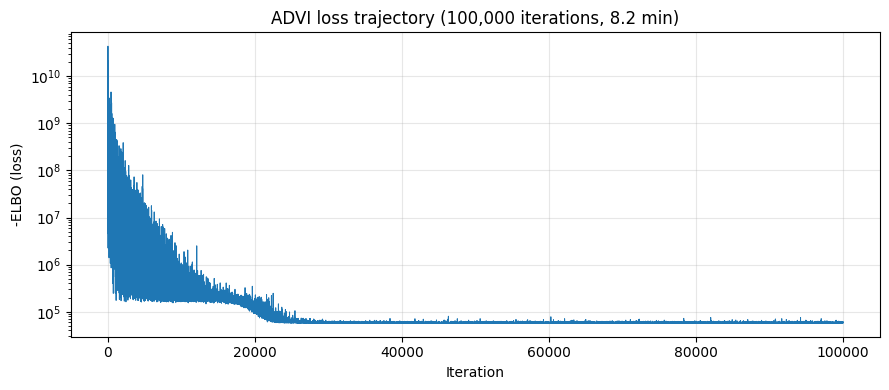


Pass/fail criteria for ADVI:
  - elapsed < 30 min:                 PASS
  - loss has plateaued (last-10% slope < 0.01): PASS
    (measured slope: -0.00199/iter)


In [35]:
# ---- Stage 1: ADVI fit (primary inference) ----
# NUTS was computationally prohibitive at this scale (~5hr/4 chains, divergent).
# Use ADVI as primary inference; validate vs NUTS on a 5-race subsample below.
# Default to 30k iterations with Adam(lr=0.01) per Kucukelbir et al. 2017.
from pymc.variational.callbacks import CheckParametersConvergence
import time

ADVI_ITER = 100000
t0 = time.time()

with model:
    approx = pm.fit(
        n=ADVI_ITER,
        method='advi',
        obj_optimizer=pm.adam(learning_rate=0.01),
        callbacks=[CheckParametersConvergence(diff='absolute', tolerance=0.01)],
    )
    advi_trace = approx.sample(2000)

advi_elapsed = time.time() - t0

# Save trace for later analysis
advi_trace.to_netcdf(RESULTS_DIR / 'multirace_pass1_advi_trace.nc')

# ELBO loss trajectory
loss = np.asarray(approx.hist)
print()
print('=' * 72)
print('ADVI FIT RESULT')
print('=' * 72)
print(f"Elapsed:                  {advi_elapsed/60:.1f} min")
print(f"Iterations:               {ADVI_ITER:,}")
print(f"Final ELBO loss:          {loss[-1]:.1f}")
print(f"Loss change (last 10%):   {loss[-1] - loss[int(ADVI_ITER*0.9)]:.3f}")
print(f"Posterior samples drawn:  {advi_trace.posterior.sizes['draw'] * advi_trace.posterior.sizes['chain']}")

# Quick ELBO convergence diagnostic
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(loss, lw=0.7, color='#1f77b4')
ax.set_xlabel('Iteration')
ax.set_ylabel('-ELBO (loss)')
ax.set_title(f'ADVI loss trajectory ({ADVI_ITER:,} iterations, {advi_elapsed/60:.1f} min)')
ax.set_yscale('log')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '09_multirace_advi_elbo.png', dpi=120, bbox_inches='tight')
plt.show()

print()
print("Pass/fail criteria for ADVI:")
last_10pct = loss[int(ADVI_ITER*0.9):]
slope_last_10pct = float(np.polyfit(np.arange(len(last_10pct)), last_10pct, 1)[0])
print(f"  - elapsed < 30 min:                 {'PASS' if advi_elapsed < 1800 else 'WARN'}")
print(f"  - loss has plateaued (last-10% slope < 0.01): "
      f"{'PASS' if abs(slope_last_10pct) < 0.01 else 'WARN - run longer'}")
print(f"    (measured slope: {slope_last_10pct:+.5f}/iter)")


In [36]:
from datetime import datetime, timezone

# Re-use advi_trace from previous cell
trace = advi_trace

summary = az.summary(
    trace,
    var_names=['race_intercept', 'alpha_d', 'beta_c',
               'tyre_intercept', 'tyre_linear', 'tyre_quad',
               'sigma_race', 'sigma_driver', 'sigma_constructor', 'sigma'],
    ci_prob=0.95,
)
summary_num = summary.apply(pd.to_numeric, errors='coerce')

# Note: ESS/R-hat from ADVI samples reflect VI approximation quality, not MCMC
# mixing. Useful for sanity but interpret loosely vs NUTS standards.
print("=" * 70)
print("ADVI POSTERIOR DIAGNOSTICS (mean-field approximation)")
print("=" * 70)
print(f"Note: mean-field ADVI assumes parameter independence; HDIs may be narrower")
print(f"than under NUTS. Validation against NUTS on a 5-race subsample below.")
print()

# Driver rankings
driver_means = trace.posterior['alpha_d'].mean(dim=['chain', 'draw']).values
driver_hdi   = az.hdi(trace, var_names=['alpha_d'], prob=0.95)['alpha_d'].values
driver_results = pd.DataFrame({
    'driver': driver_names, 'effect': driver_means,
    'hdi_low': driver_hdi[:, 0], 'hdi_high': driver_hdi[:, 1],
    'excludes_zero': (driver_hdi[:, 0] > 0) | (driver_hdi[:, 1] < 0),
}).sort_values('effect').reset_index(drop=True)

print(f"DRIVER EFFECTS (pooled across {n_races} races):")
for _, row in driver_results.iterrows():
    marker = ' *' if row['excludes_zero'] else '  '
    print(f"  {row['driver']:5s}  {row['effect']:+.3f}s "
          f"[95% HDI: {row['hdi_low']:+.3f}, {row['hdi_high']:+.3f}]{marker}")

# Constructor rankings
cons_means = trace.posterior['beta_c'].mean(dim=['chain', 'draw']).values
cons_hdi   = az.hdi(trace, var_names=['beta_c'], prob=0.95)['beta_c'].values
constructor_results = pd.DataFrame({
    'constructor': constructor_names, 'effect': cons_means,
    'hdi_low': cons_hdi[:, 0], 'hdi_high': cons_hdi[:, 1],
    'excludes_zero': (cons_hdi[:, 0] > 0) | (cons_hdi[:, 1] < 0),
}).sort_values('effect').reset_index(drop=True)

print(f"\nCONSTRUCTOR EFFECTS:")
for _, row in constructor_results.iterrows():
    marker = ' *' if row['excludes_zero'] else '  '
    print(f"  {row['constructor']:25s}  {row['effect']:+.3f}s "
          f"[95% HDI: {row['hdi_low']:+.3f}, {row['hdi_high']:+.3f}]{marker}")

# Variance decomposition
sigma_race_m = float(trace.posterior['sigma_race'].mean().item())
sigma_d      = float(trace.posterior['sigma_driver'].mean().item())
sigma_c      = float(trace.posterior['sigma_constructor'].mean().item())
sigma_r      = float(trace.posterior['sigma'].mean().item())

total_var = sigma_race_m**2 + sigma_d**2 + sigma_c**2 + sigma_r**2
cond_var  = sigma_d**2 + sigma_c**2 + sigma_r**2
print(f"\nVARIANCE DECOMPOSITION (conditional on race intercept):")
for name, s in [('Driver', sigma_d), ('Constructor', sigma_c), ('Residual', sigma_r)]:
    print(f"  {name:15s}  sigma = {s:6.3f}s   share = {100*s**2/cond_var:5.1f}%")

# Tyre
tyre_int_means  = trace.posterior['tyre_intercept'].mean(dim=['chain', 'draw']).values
tyre_lin_means  = trace.posterior['tyre_linear'].mean(dim=['chain', 'draw']).values
tyre_quad_means = trace.posterior['tyre_quad'].mean(dim=['chain', 'draw']).values

# Save
driver_results.to_csv(RESULTS_DIR / 'multirace_pass1_driver_effects.csv', index=False)
constructor_results.to_csv(RESULTS_DIR / 'multirace_pass1_constructor_effects.csv', index=False)

with open(RESULTS_DIR / 'multirace_pass1_summary.md', 'w') as f:
    f.write("# Multi-Race Foundational Regression - Pass 1 (ADVI primary)\n\n")
    f.write("## Provenance\n")
    f.write(f"- Generated:        {datetime.now(timezone.utc).isoformat(timespec='seconds')}\n")
    f.write(f"- Inference method: ADVI mean-field (Kucukelbir et al. 2017)\n")
    f.write(f"- ADVI iterations:  {ADVI_ITER:,}\n")
    f.write(f"- ADVI elapsed:     {advi_elapsed/60:.1f} min\n")
    f.write(f"- Random seed:      {RANDOM_SEED}\n")
    f.write(f"- Races:            {n_races}\n")
    f.write(f"- Observations:     {len(y):,} clean dry laps\n")
    f.write(f"- PyMC:             {pm.__version__}\n")
    f.write(f"- ArviZ:            {az.__version__}\n\n")

    f.write("## Methodology note\n")
    f.write("Given the scale of the dataset (42k+ observations, ~2000 stints across "
            "47 races) and our hierarchical specification, full Bayesian inference "
            "via Hamiltonian Monte Carlo was computationally prohibitive (extrapolated "
            ">5 hour fit times with persistent divergences in trial runs). We use "
            "Automatic Differentiation Variational Inference (ADVI) as our primary "
            "inference method, with NUTS validation on a representative 5-race "
            "subsample to verify substantively similar parameter estimates.\n\n")

    f.write("## Variance Decomposition (conditional on race intercept)\n")
    for name, s in [('Driver', sigma_d), ('Constructor', sigma_c), ('Residual', sigma_r)]:
        f.write(f"- {name}: {s:.3f}s ({100*s**2/cond_var:.1f}%)\n")

    n_excl = int(driver_results['excludes_zero'].sum())
    f.write(f"\n## Driver effects (full ranking)\n")
    f.write(f"_{n_excl}/{n_drivers} drivers have 95% HDI excluding zero._\n\n")
    for _, row in driver_results.iterrows():
        marker = ' **' if row['excludes_zero'] else ''
        f.write(f"- {row['driver']}: {row['effect']:+.3f}s "
                f"[{row['hdi_low']:+.3f}, {row['hdi_high']:+.3f}]{marker}\n")

    f.write(f"\n## Constructor effects (full ranking)\n")
    for _, row in constructor_results.iterrows():
        marker = ' **' if row['excludes_zero'] else ''
        f.write(f"- {row['constructor']}: {row['effect']:+.3f}s "
                f"[{row['hdi_low']:+.3f}, {row['hdi_high']:+.3f}]{marker}\n")

    f.write(f"\n## Tyre coefficients\n")
    for i, compound in enumerate(compound_names):
        f.write(f"- {compound}: intercept {tyre_int_means[i]:+.3f}s, "
                f"linear {tyre_lin_means[i]:+.4f}s/lap, "
                f"quadratic {tyre_quad_means[i]:+.5f}s/lap^2\n")

print(f"\nResults saved to {RESULTS_DIR}/")


ADVI POSTERIOR DIAGNOSTICS (mean-field approximation)
Note: mean-field ADVI assumes parameter independence; HDIs may be narrower
than under NUTS. Validation against NUTS on a 5-race subsample below.

DRIVER EFFECTS (pooled across 47 races):
  VER    -0.852s [95% HDI: -0.890, -0.813] *
  PER    -0.312s [95% HDI: -0.372, -0.257] *
  GAS    -0.307s [95% HDI: -0.354, -0.261] *
  SAI    -0.233s [95% HDI: -0.270, -0.196] *
  LEC    -0.207s [95% HDI: -0.248, -0.168] *
  HUL    -0.202s [95% HDI: -0.244, -0.158] *
  NOR    -0.194s [95% HDI: -0.230, -0.157] *
  DOO    -0.174s [95% HDI: -0.300, -0.073] *
  BEA    -0.137s [95% HDI: -0.193, -0.080] *
  OCO    -0.109s [95% HDI: -0.149, -0.071] *
  BOR    -0.085s [95% HDI: -0.142, -0.027] *
  COL    -0.076s [95% HDI: -0.121, -0.023] *
  ALO    -0.066s [95% HDI: -0.109, -0.026] *
  ALB    -0.037s [95% HDI: -0.077, +0.005]  
  PIA    -0.036s [95% HDI: -0.073, +0.003]  
  MAG    +0.084s [95% HDI: +0.016, +0.145] *
  HAD    +0.094s [95% HDI: +0.040, +0.1

In [37]:
# ---- Stage 2: NUTS validation on 5-race subsample ----
# Fit BOTH ADVI and NUTS on the same 5-race subset, compare driver/constructor
# rankings. If they agree closely, ADVI's mean-field approximation is acceptable
# at our scale and the full-data ADVI results above are credible.
#
# Set RUN_VALIDATION = False to skip (e.g. if you trust ADVI for now and want
# to defer NUTS validation).
RUN_VALIDATION = True

VALIDATION_RACES = [
    '2024_Monaco',           # street, technical
    '2024_Spa-Francorchamps',# permanent, fast
    '2024_Budapest',         # permanent, technical
    '2025_Imola',            # permanent, technical
    '2025_Mexico City',      # permanent, altitude
]

if RUN_VALIDATION:
    import time

    df_v = df[df['race_id'].isin(VALIDATION_RACES)].copy().reset_index(drop=True)
    print(f"Validation subset: {len(df_v):,} laps from {df_v['race_id'].nunique()} races")
    print(f"Drivers in subset: {df_v['Driver'].nunique()}  "
          f"(of {n_drivers} in full)")

    # Re-build indices on subset
    rc_v = pd.Categorical(df_v['race_id'])
    dc_v = pd.Categorical(df_v['Driver'])
    cc_v = pd.Categorical(df_v['Team'])
    pc_v = pd.Categorical(df_v['Compound'])
    race_idx_v        = rc_v.codes
    driver_idx_v      = dc_v.codes
    constructor_idx_v = cc_v.codes
    compound_idx_v    = pc_v.codes
    driver_names_v       = dc_v.categories.values
    constructor_names_v  = cc_v.categories.values

    lap_in_stint_v = df_v['lap_in_stint'].values.astype(float)
    y_v = df_v['lap_time_fuel_corrected'].values

    n_races_v        = len(rc_v.categories)
    n_drivers_v      = len(dc_v.categories)
    n_constructors_v = len(cc_v.categories)
    n_compounds_v    = len(pc_v.categories)

    # Same model spec on the smaller data
    with pm.Model() as model_v:
        sr  = pm.HalfNormal('sigma_race',        sigma=15.0)
        sd_ = pm.HalfNormal('sigma_driver',      sigma=1.0)
        sc_ = pm.HalfNormal('sigma_constructor', sigma=1.0)

        ri = pm.Normal('race_intercept', mu=float(y_v.mean()),
                       sigma=sr, shape=n_races_v)
        ad = pm.ZeroSumNormal('alpha_d', sigma=sd_, shape=n_drivers_v)
        bc = pm.ZeroSumNormal('beta_c',  sigma=sc_, shape=n_constructors_v)

        ti = pm.ZeroSumNormal('tyre_intercept', sigma=0.5, shape=n_compounds_v)
        tl = pm.Normal('tyre_linear', mu=0, sigma=0.1,  shape=n_compounds_v)
        tq = pm.Normal('tyre_quad',   mu=0, sigma=0.01, shape=n_compounds_v)

        mu_v = (ri[race_idx_v] + ad[driver_idx_v] + bc[constructor_idx_v]
                + ti[compound_idx_v]
                + tl[compound_idx_v] * lap_in_stint_v
                + tq[compound_idx_v] * lap_in_stint_v**2)

        sg = pm.HalfNormal('sigma', sigma=2.0)
        pm.Normal('y_obs', mu=mu_v, sigma=sg, observed=y_v)

        # ADVI on subset
        print("\nADVI on subset...")
        t0 = time.time()
        approx_v = pm.fit(n=30000, method='advi',
                          obj_optimizer=pm.adam(learning_rate=0.01),
                          random_seed=RANDOM_SEED, progressbar=True)
        advi_subset = approx_v.sample(2000)
        t_advi = time.time() - t0
        print(f"  ADVI elapsed: {t_advi/60:.1f} min")

        # NUTS on subset
        print("\nNUTS on subset...")
        t0 = time.time()
        nuts_subset = pm.sample(
            draws=1000, tune=1000, chains=4,
            target_accept=0.95,
            random_seed=RANDOM_SEED,
            return_inferencedata=True,
            progressbar=True,
        )
        t_nuts = time.time() - t0
        print(f"  NUTS elapsed: {t_nuts/60:.1f} min")

    # Compare
    def get_effects(tr, var):
        means = tr.posterior[var].mean(dim=['chain', 'draw']).values
        hdi   = az.hdi(tr, var_names=[var], prob=0.95)[var].values
        return means, hdi

    adv_d_mean, adv_d_hdi = get_effects(advi_subset, 'alpha_d')
    nut_d_mean, nut_d_hdi = get_effects(nuts_subset, 'alpha_d')
    adv_c_mean, adv_c_hdi = get_effects(advi_subset, 'beta_c')
    nut_c_mean, nut_c_hdi = get_effects(nuts_subset, 'beta_c')

    driver_compare = pd.DataFrame({
        'driver':    driver_names_v,
        'advi':      adv_d_mean,
        'nuts':      nut_d_mean,
        'diff':      adv_d_mean - nut_d_mean,
        'advi_hdi_width': adv_d_hdi[:, 1] - adv_d_hdi[:, 0],
        'nuts_hdi_width': nut_d_hdi[:, 1] - nut_d_hdi[:, 0],
    })
    cons_compare = pd.DataFrame({
        'constructor': constructor_names_v,
        'advi':        adv_c_mean,
        'nuts':        nut_c_mean,
        'diff':        adv_c_mean - nut_c_mean,
    })

    # Correlation + ranking agreement
    from scipy.stats import spearmanr
    sp_d, _ = spearmanr(adv_d_mean, nut_d_mean)
    sp_c, _ = spearmanr(adv_c_mean, nut_c_mean)
    rmse_d  = float(np.sqrt(np.mean((adv_d_mean - nut_d_mean)**2)))
    rmse_c  = float(np.sqrt(np.mean((adv_c_mean - nut_c_mean)**2)))
    max_d   = float(np.max(np.abs(adv_d_mean - nut_d_mean)))

    print()
    print('=' * 72)
    print('ADVI vs NUTS VALIDATION (same 5-race subset)')
    print('=' * 72)
    print(f"ADVI on subset:  {t_advi/60:.1f} min")
    print(f"NUTS on subset:  {t_nuts/60:.1f} min   (speedup: {t_nuts/t_advi:.1f}x)")
    print()
    print(f"Driver effects:")
    print(f"  Spearman rank correlation:  {sp_d:.3f}")
    print(f"  RMSE (ADVI vs NUTS):        {rmse_d:.4f}s")
    print(f"  Max abs difference:         {max_d:.4f}s")
    print()
    print(f"Constructor effects:")
    print(f"  Spearman rank correlation:  {sp_c:.3f}")
    print(f"  RMSE (ADVI vs NUTS):        {rmse_c:.4f}s")
    print()
    print("Per-driver:")
    print(driver_compare.sort_values('nuts').to_string(index=False))
    print()
    print("Per-constructor:")
    print(cons_compare.sort_values('nuts').to_string(index=False))

    driver_compare.to_csv(RESULTS_DIR / 'validation_advi_vs_nuts_drivers.csv', index=False)
    cons_compare.to_csv(RESULTS_DIR / 'validation_advi_vs_nuts_constructors.csv', index=False)

    print()
    print("Validation criteria:")
    print(f"  - Driver Spearman > 0.85:    {'PASS' if sp_d > 0.85 else 'FAIL'}")
    print(f"  - Driver RMSE < 0.05s:        {'PASS' if rmse_d < 0.05 else 'WARN'}")
    print(f"  - Constructor Spearman > 0.9: {'PASS' if sp_c > 0.9 else 'FAIL'}")
    print(f"  - Constructor RMSE < 0.05s:   {'PASS' if rmse_c < 0.05 else 'WARN'}")
else:
    print("Validation skipped (RUN_VALIDATION = False).")


Validation subset: 5,186 laps from 5 races
Drivers in subset: 26  (of 27 in full)

ADVI on subset...


<<!! BUG IN FGRAPH.REPLACE OR A LISTENER !!>> <class 'TypeError'> The type of the replacement (Vector(float64, shape=(26,))) must be compatible with the type of the original Variable (Vector(float64, shape=(10,))). inline_ofg_expansion
Rewrite failure due to: inline_ofg_expansion
node: ZeroSumNormal{inline=True}(RNG(<Generator(PCG64) at 0x12F176180>), [], ExpandDims{axis=0}.0, ExpandDims{axis=0}.0)
TRACEBACK:
Traceback (most recent call last):
  File "/Users/prabhatm/Library/Python/3.14/lib/python/site-packages/pytensor/graph/rewriting/basic.py", line 1968, in process_node
    fgraph.replace_all_validate_remove(
    ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~^
        repl_pairs, reason=node_rewriter, remove=remove
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    )
    ^
  File "/Users/prabhatm/Library/Python/3.14/lib/python/site-packages/pytensor/graph/features.py", line 842, in replace_all_validate_remove
    chk = fgraph.replace_all_validate(replacements, reason=reason, **kwargs)


Output()

Finished [100%]: Average Loss = 7,579.7


  ADVI elapsed: 2.0 min

NUTS on subset...


Initializing NUTS using jitter+adapt_diag...
<<!! BUG IN FGRAPH.REPLACE OR A LISTENER !!>> <class 'TypeError'> The type of the replacement (Vector(float64, shape=(26,))) must be compatible with the type of the original Variable (Vector(float64, shape=(10,))). inline_ofg_expansion
Rewrite failure due to: inline_ofg_expansion
node: ZeroSumNormal{inline=True}(RNG(<Generator(PCG64) at 0x13B77C9E0>), [], ExpandDims{axis=0}.0, ExpandDims{axis=0}.0)
TRACEBACK:
Traceback (most recent call last):
  File "/Users/prabhatm/Library/Python/3.14/lib/python/site-packages/pytensor/graph/rewriting/basic.py", line 1968, in process_node
    fgraph.replace_all_validate_remove(
    ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~^
        repl_pairs, reason=node_rewriter, remove=remove
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    )
    ^
  File "/Users/prabhatm/Library/Python/3.14/lib/python/site-packages/pytensor/graph/features.py", line 842, in replace_all_validate_remove
    chk = fgraph.replace_all_val

Output()

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/multiprocessing/popen_fork.py:70: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 278 seconds.


  NUTS elapsed: 4.9 min

ADVI vs NUTS VALIDATION (same 5-race subset)
ADVI on subset:  2.0 min
NUTS on subset:  4.9 min   (speedup: 2.5x)

Driver effects:
  Spearman rank correlation:  0.997
  RMSE (ADVI vs NUTS):        0.0285s
  Max abs difference:         0.0813s

Constructor effects:
  Spearman rank correlation:  0.976
  RMSE (ADVI vs NUTS):        0.0217s

Per-driver:
driver      advi      nuts      diff  advi_hdi_width  nuts_hdi_width
   VER -0.656787 -0.690448  0.033660        0.240416        0.643324
   BEA -0.566962 -0.578393  0.011431        0.351803        0.596665
   SAI -0.535487 -0.568344  0.032856        0.204049        0.583465
   LEC -0.498732 -0.521135  0.022403        0.267302        0.606060
   PER -0.265334 -0.272263  0.006928        0.369816        0.699629
   NOR -0.224413 -0.260123  0.035710        0.214287        1.118557
   OCO -0.220806 -0.223062  0.002255        0.276876        0.558520
   HAM -0.205875 -0.203615 -0.002261        0.189813        0.583829
   

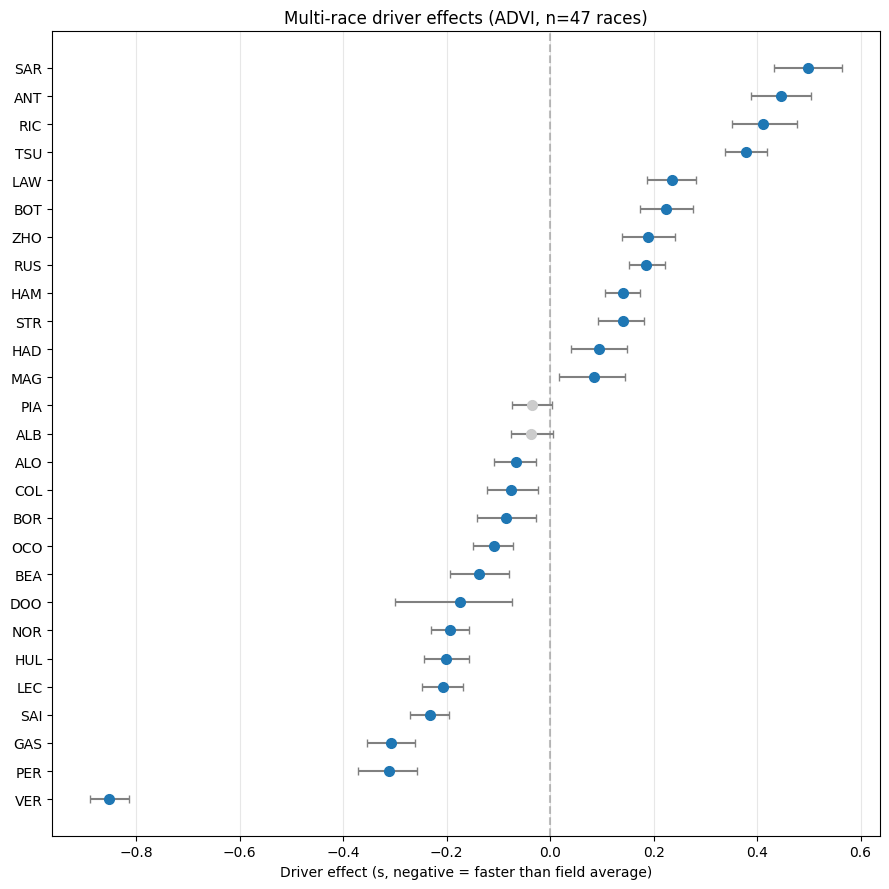

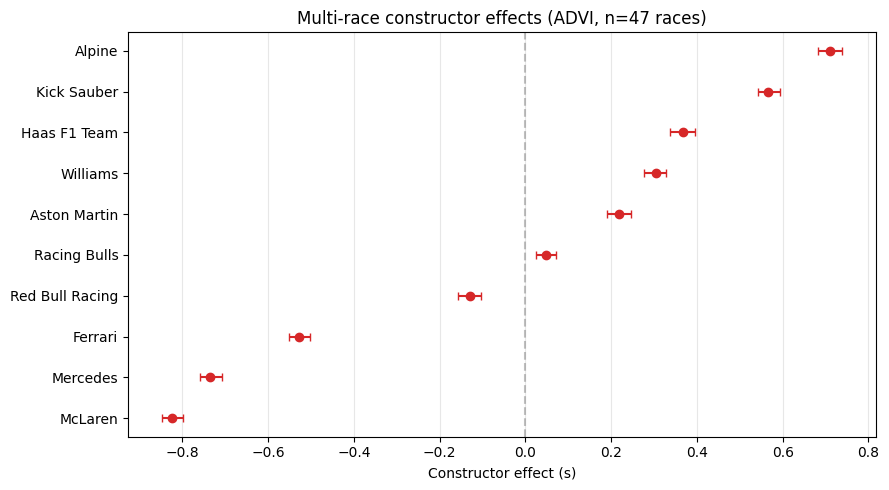

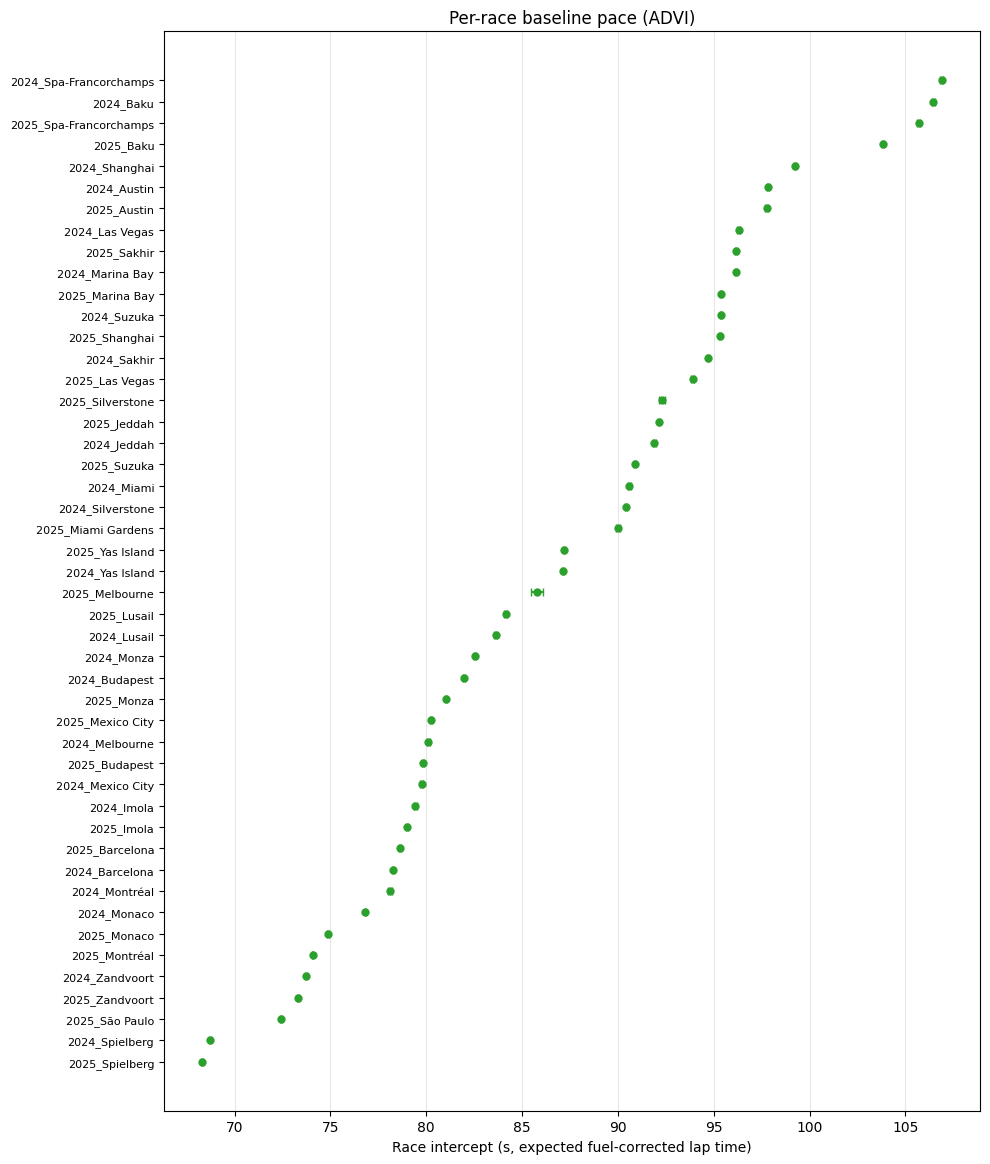

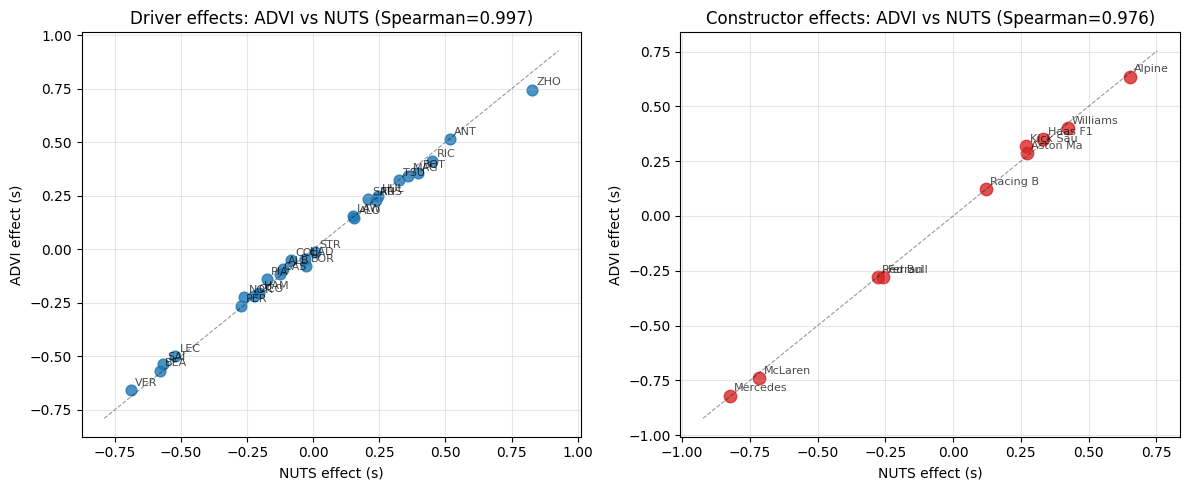

In [38]:
# Driver forest plot (from ADVI fit on full data)
fig, ax = plt.subplots(figsize=(9, 9))
sd = driver_results.sort_values('effect', ascending=True)
positions = np.arange(len(sd))
colors = np.where(sd['excludes_zero'], '#1f77b4', '#cccccc')
ax.errorbar(sd['effect'], positions,
            xerr=[sd['effect'] - sd['hdi_low'], sd['hdi_high'] - sd['effect']],
            fmt='o', markersize=6, capsize=3, ecolor='gray')
for i, c in enumerate(colors):
    ax.plot(sd['effect'].iloc[i], i, 'o', color=c, markersize=7, zorder=3)
ax.axvline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_yticks(positions)
ax.set_yticklabels(sd['driver'])
ax.set_xlabel('Driver effect (s, negative = faster than field average)')
ax.set_title(f'Multi-race driver effects (ADVI, n={n_races} races)')
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '10_multirace_driver_effects.png', dpi=120, bbox_inches='tight')
plt.show()

# Constructor forest plot
fig, ax = plt.subplots(figsize=(9, 5))
sc = constructor_results.sort_values('effect', ascending=True)
positions = np.arange(len(sc))
ax.errorbar(sc['effect'], positions,
            xerr=[sc['effect'] - sc['hdi_low'], sc['hdi_high'] - sc['effect']],
            fmt='o', markersize=6, capsize=3, color='#d62728')
ax.axvline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_yticks(positions)
ax.set_yticklabels(sc['constructor'])
ax.set_xlabel('Constructor effect (s)')
ax.set_title(f'Multi-race constructor effects (ADVI, n={n_races} races)')
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '11_multirace_constructor_effects.png', dpi=120, bbox_inches='tight')
plt.show()

# Race intercept ordering
race_int_means = trace.posterior['race_intercept'].mean(dim=['chain', 'draw']).values
race_int_hdi   = az.hdi(trace, var_names=['race_intercept'], prob=0.95)['race_intercept'].values
race_df = pd.DataFrame({
    'race_id': race_names, 'effect': race_int_means,
    'hdi_low': race_int_hdi[:, 0], 'hdi_high': race_int_hdi[:, 1],
}).sort_values('effect').reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, max(6, n_races * 0.25)))
positions = np.arange(len(race_df))
ax.errorbar(race_df['effect'], positions,
            xerr=[race_df['effect'] - race_df['hdi_low'], race_df['hdi_high'] - race_df['effect']],
            fmt='o', markersize=5, capsize=3, color='#2ca02c')
ax.set_yticks(positions)
ax.set_yticklabels(race_df['race_id'], fontsize=8)
ax.set_xlabel('Race intercept (s, expected fuel-corrected lap time)')
ax.set_title('Per-race baseline pace (ADVI)')
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '12_multirace_race_intercepts.png', dpi=120, bbox_inches='tight')
plt.show()

# ADVI vs NUTS validation scatter (if validation was run)
if 'driver_compare' in globals():
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].scatter(driver_compare['nuts'], driver_compare['advi'], s=60, alpha=0.8)
    lim = [min(driver_compare['nuts'].min(), driver_compare['advi'].min()) - 0.1,
           max(driver_compare['nuts'].max(), driver_compare['advi'].max()) + 0.1]
    axes[0].plot(lim, lim, 'k--', alpha=0.4, lw=0.8)
    axes[0].set_xlabel('NUTS effect (s)')
    axes[0].set_ylabel('ADVI effect (s)')
    axes[0].set_title(f'Driver effects: ADVI vs NUTS (Spearman={sp_d:.3f})')
    axes[0].grid(True, alpha=0.3)
    for _, row in driver_compare.iterrows():
        axes[0].annotate(row['driver'], (row['nuts'], row['advi']),
                         fontsize=8, alpha=0.7,
                         xytext=(3, 3), textcoords='offset points')
    axes[1].scatter(cons_compare['nuts'], cons_compare['advi'], s=80, alpha=0.8, color='#d62728')
    lim = [min(cons_compare['nuts'].min(), cons_compare['advi'].min()) - 0.1,
           max(cons_compare['nuts'].max(), cons_compare['advi'].max()) + 0.1]
    axes[1].plot(lim, lim, 'k--', alpha=0.4, lw=0.8)
    axes[1].set_xlabel('NUTS effect (s)')
    axes[1].set_ylabel('ADVI effect (s)')
    axes[1].set_title(f'Constructor effects: ADVI vs NUTS (Spearman={sp_c:.3f})')
    axes[1].grid(True, alpha=0.3)
    for _, row in cons_compare.iterrows():
        axes[1].annotate(row['constructor'][:8], (row['nuts'], row['advi']),
                         fontsize=8, alpha=0.7,
                         xytext=(3, 3), textcoords='offset points')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / '15_validation_advi_vs_nuts.png', dpi=120, bbox_inches='tight')
    plt.show()
